In [36]:
import matplotlib.pyplot
import pandas
import tarfile

In [64]:
# Colorblind safe, print friendly
colorblind_safe_colors = {
    'latency'  : '#1b9e77',
    'replicas' : '#d95f02',
    'other'    : '#7570b3',
}

def parse_replicas(file_path : str) -> list[int]:
    replicas : list[int] = []

    with (open(f"{file_path}/replicas.log")) as file:
        for line in file:
            parts : list[str] = line.split()
            if "crust" in parts[0]:
                replicas.append(int(parts[6]))
    
    return replicas

def parse_cpu_utilization(file_path : str) -> list[int]:
    cpu_utilization : list[int] = []

    with (open(f"{file_path}/replicas.log")) as file:
        for line in file:
            parts : list[str] = line.split()
            if "crust" in parts[0]:
                current, _ = parts[3].split("/")
                if current == "<unknown>":
                    cpu_utilization.append(0)
                    continue
                cpu_utilization.append(int(current.rstrip("%")))

    return cpu_utilization

def parse_p99(file_path : str) -> pandas.Series:
    columns : list[str] = ['timestamp_ns', 'status', 'latency_ns']
    data_frames : list[pandas.DataFrame] = [
        pandas.read_csv(f"{file_path}/vegeta1.log", usecols=[0, 1, 2], header=None, names=columns),
        pandas.read_csv(f"{file_path}/vegeta2.log", usecols=[0, 1, 2], header=None, names=columns),
        pandas.read_csv(f"{file_path}/vegeta3.log", usecols=[0, 1, 2], header=None, names=columns),
    ]
    combined_data_frame : pandas.DataFrame = pandas.concat(data_frames, ignore_index=True)

    combined_data_frame['timestamp_ns'] = pandas.to_datetime(combined_data_frame['timestamp_ns'], unit='ns')
    combined_data_frame = combined_data_frame.set_index('timestamp_ns')

    return combined_data_frame['latency_ns'].resample('1s').quantile(0.99).expanding().mean() / 1e6
    #return combined_data_frame['latency_ns'].resample('1s').quantile(0.99) / 1e6

def plot_replicas(file_path : str) -> None:
    replicas = parse_replicas(file_path)

    matplotlib.pyplot.plot(replicas, color=colorblind_safe_colors['replicas'])
    matplotlib.pyplot.axvline(x = 0, linestyle = '--', color=colorblind_safe_colors['other'])
    matplotlib.pyplot.axvline(x = 60, linestyle = '--', color=colorblind_safe_colors['other'])
    matplotlib.pyplot.axvline(x = 240, linestyle = '--', color=colorblind_safe_colors['other'])
    matplotlib.pyplot.xlabel("Time (s)")
    matplotlib.pyplot.ylabel("Replica Count") 
    matplotlib.pyplot.legend()
    matplotlib.pyplot.tight_layout()
    matplotlib.pyplot.show()
    
def plot_p99(file_path : str) -> None:
    latencies = parse_p99(file_path)

    matplotlib.pyplot.plot(latencies.to_numpy(), color=colorblind_safe_colors['latency'])
    matplotlib.pyplot.axvline(x = 0, linestyle = '--', color=colorblind_safe_colors['other'])
    matplotlib.pyplot.axvline(x = 60, linestyle = '--', color=colorblind_safe_colors['other'])
    matplotlib.pyplot.axvline(x = 240, linestyle = '--', color=colorblind_safe_colors['other'])
    matplotlib.pyplot.xlabel("Time (s)")
    matplotlib.pyplot.ylabel("P99 Latency (ms)")
    matplotlib.pyplot.legend()
    matplotlib.pyplot.tight_layout()
    matplotlib.pyplot.show()

def plot_replicas_and_cpu_utilization(file_path : str) -> None:
    replicas        = parse_replicas(file_path)
    cpu_utilization = parse_cpu_utilization(file_path)
    latencies       = parse_p99(file_path)

    fig, ax1 = matplotlib.pyplot.subplots(figsize=(12, 5))

    ax1.set_xlabel("Time (samples)")
    ax1.set_ylabel("Replicas", color=colorblind_safe_colors['replicas'])
    ax1.plot(replicas, color=colorblind_safe_colors['replicas'], label="Replicas")
    ax1.tick_params(axis="y", labelcolor=colorblind_safe_colors['replicas'])
    ax1.set_xticks(range(0, max(len(replicas), len(latencies)), 60))

    ax2 = ax1.twinx()
    ax2.set_ylabel("CPU Utilization", color=colorblind_safe_colors['latency'])
    ax2.plot(cpu_utilization, color=colorblind_safe_colors['latency'], label="CPU Utilization")
    ax2.tick_params(axis="y", labelcolor=colorblind_safe_colors['latency'])
    #ax2.set_ylabel("Average P99 Latency (ms)", color=colors['latency'])
    #ax2.plot(latencies.to_numpy(), color=colors['latency'], label="P99 Latency")
    #ax2.tick_params(axis="y", labelcolor=colors['latency'])

    matplotlib.pyplot.axvline(x = 0, linestyle = '--', color=colorblind_safe_colors['other'])
    matplotlib.pyplot.axvline(x = 60, linestyle = '--', color=colorblind_safe_colors['other'])
    matplotlib.pyplot.axvline(x = 240, linestyle = '--', color=colorblind_safe_colors['other'])

    matplotlib.pyplot.title("Replicas vs P99")
    fig.tight_layout()
    fig.show()

def plot_replicas_and_p99_latency(file_path : str) -> None:
    replicas        = parse_replicas(file_path)
    cpu_utilization = parse_cpu_utilization(file_path)
    latencies       = parse_p99(file_path)

    fig, ax1 = matplotlib.pyplot.subplots(figsize=(12, 5))

    ax1.set_xlabel("Time (samples)")
    ax1.set_ylabel("Replicas", color=colorblind_safe_colors['replicas'])
    ax1.plot(replicas, color=colorblind_safe_colors['replicas'], label="Replicas")
    ax1.tick_params(axis="y", labelcolor=colorblind_safe_colors['replicas'])
    ax1.set_xticks(range(0, max(len(replicas), len(latencies)), 60))

    ax2 = ax1.twinx()
    ax2.set_ylabel("Average P99 Latency (ms)", color=colorblind_safe_colors['latency'])
    ax2.plot(latencies.to_numpy(), color=colorblind_safe_colors['latency'], label="P99 Latency")
    ax2.tick_params(axis="y", labelcolor=colorblind_safe_colors['latency'])

    matplotlib.pyplot.axvline(x = 0, linestyle = '--', color=colorblind_safe_colors['other'])
    matplotlib.pyplot.axvline(x = 60, linestyle = '--', color=colorblind_safe_colors['other'])
    matplotlib.pyplot.axvline(x = 240, linestyle = '--', color=colorblind_safe_colors['other'])

    matplotlib.pyplot.title("Replicas vs P99")
    fig.tight_layout()
    fig.show()

def plot_replicas_and_p99_latency_comparison(experiments : list[tuple[str, str]]) -> None:
    fig, ax1 = matplotlib.pyplot.subplots(figsize=(12, 5))
    ax2 = ax1.twinx()

    colors = matplotlib.pyplot.rcParams['axes.prop_cycle'].by_key()['color']
    max_len = 0

    for i, (file_path, name) in enumerate(experiments):
        color = colors[i % len(colors)]
        replicas = parse_replicas(file_path)
        latencies = parse_p99(file_path)
        max_len = max(max_len, len(replicas), len(latencies))

        ax1.plot(replicas, color=color, linestyle="-", label=f"{name}")
        ax2.plot(latencies.to_numpy(), color=color, linestyle="--")

    ax1.set_xlabel("Time (samples)")
    ax1.set_ylabel("Replicas")
    ax1.set_xticks(range(0, max_len, 60))
    ax2.set_ylabel("Average Running P99 Latency (ms)")

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

    matplotlib.pyplot.title("Replicas vs P99 Comparison")
    fig.tight_layout()
    fig.show()

def plot_replicas_and_cpu_utilization_comparison(experiments : list[tuple[str, str]]) -> None:
    fig, ax1 = matplotlib.pyplot.subplots(figsize=(12, 5))
    ax2 = ax1.twinx()

    colors = matplotlib.pyplot.rcParams['axes.prop_cycle'].by_key()['color']
    max_len = 0

    for i, (file_path, name) in enumerate(experiments):
        color = colors[i % len(colors)]
        replicas = parse_replicas(file_path)
        cpu_utilization = parse_cpu_utilization(file_path)
        max_len = max(max_len, len(replicas), len(cpu_utilization))

        ax1.plot(replicas, color=color, linestyle="-", label=f"{name}")
        ax2.plot(cpu_utilization, color=color, linestyle="--")

    ax1.set_xlabel("Time (samples)")
    ax1.set_ylabel("Replicas")
    ax1.set_xticks(range(0, max_len, 60))
    ax2.set_ylabel("CPU Utilization")

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

    matplotlib.pyplot.title("Replicas vs CPU Utilization Comparison")
    fig.tight_layout()
    fig.show()

/tmp/ipykernel_11604/3005136834.py:186: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


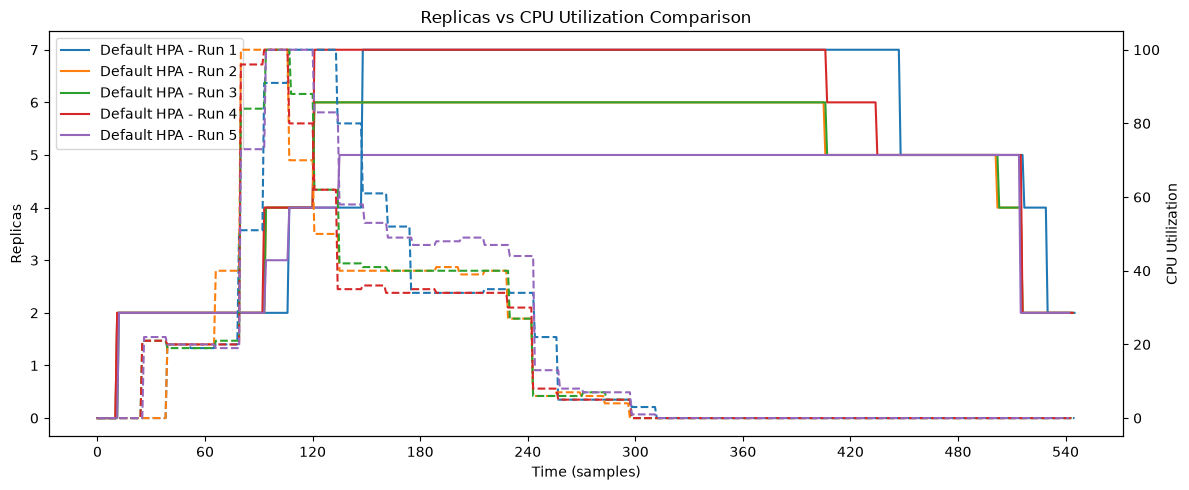

In [66]:
plot_replicas_and_cpu_utilization_comparison([
    ("results/default_hpa/experiment_run_1", "Default HPA - Run 1"),
    ("results/default_hpa/experiment_run_2", "Default HPA - Run 2"),
    ("results/default_hpa/experiment_run_3", "Default HPA - Run 3"),
    ("results/default_hpa/experiment_run_4", "Default HPA - Run 4"),
    ("results/default_hpa/experiment_run_5", "Default HPA - Run 5"),
]);

/tmp/ipykernel_11604/3005136834.py:157: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


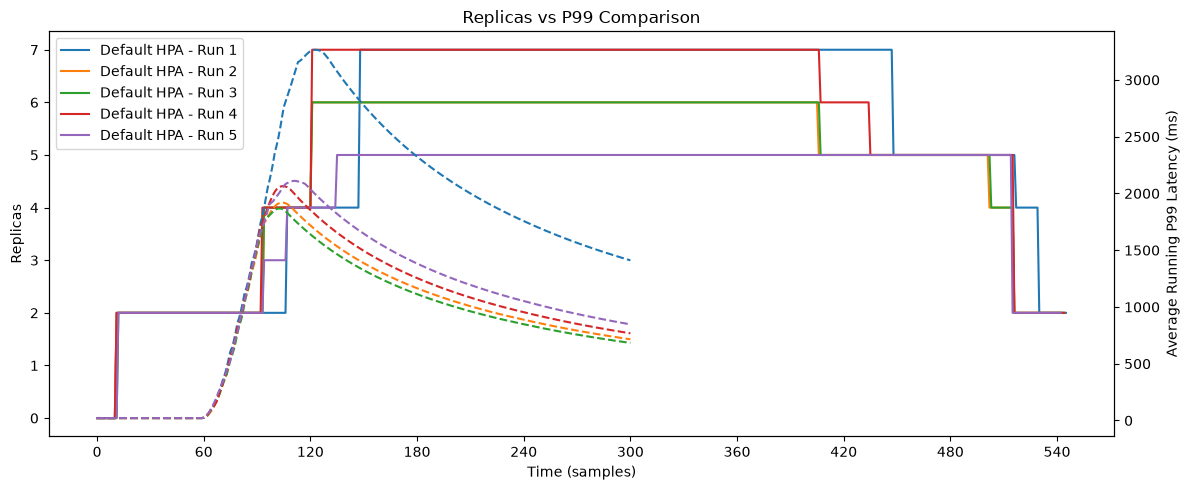

In [67]:
plot_replicas_and_p99_latency_comparison([
    ("results/default_hpa/experiment_run_1", "Default HPA - Run 1"),
    ("results/default_hpa/experiment_run_2", "Default HPA - Run 2"),
    ("results/default_hpa/experiment_run_3", "Default HPA - Run 3"),
    ("results/default_hpa/experiment_run_4", "Default HPA - Run 4"),
    ("results/default_hpa/experiment_run_5", "Default HPA - Run 5"),
]);